In [12]:
# Load FPKM matrix — column names encode time/condition annotations
# Format: CK_2w_m2_A1 → condition_timepoint_mouse_well
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
from src.cf_recon import reconstruct_cf
from matplotlib.patches import Patch

save_dir = Path('../outputs/GSE103334').mkdir(exist_ok=True)

data_file = Path('../data/GSE103334/GSE103334_FPKM_CKP25_TOPHAT.txt.gz')
expr_df = pd.read_csv(data_file, sep='\t', compression='gzip', index_col=0)

print(f"Expression matrix: {expr_df.shape[0]:,} genes × {expr_df.shape[1]:,} cells")
print(f"Sample cell names: {expr_df.columns[:5].tolist()}")
%load_ext autoreload

Expression matrix: 23,951 genes × 2,208 cells
Sample cell names: ['CK_0w_m3_A1', 'CK_0w_m3_A10', 'CK_0w_m3_A11', 'CK_0w_m3_A12', 'CK_0w_m3_A2']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Parse metadata from cell names and build AnnData
cell_meta = []
for cell_name in expr_df.columns:
    parts = cell_name.split('_')
    cell_meta.append({
        'condition': parts[0],
        'time_point': parts[1],
        'mouse': parts[2],
    })
cell_meta_df = pd.DataFrame(cell_meta, index=expr_df.columns)

# Build AnnData: rows = cells, cols = genes
adata_time = sc.AnnData(X=expr_df.T.values)
adata_time.obs_names = expr_df.columns.tolist()
adata_time.var_names = expr_df.index.tolist()
adata_time.obs[['condition', 'time_point', 'mouse']] = cell_meta_df[['condition', 'time_point', 'mouse']]

print(adata_time)
print(f"\nConditions : {sorted(adata_time.obs['condition'].unique())}")
print(f"Time points: {sorted(adata_time.obs['time_point'].unique())}")
print(f"Mice       : {sorted(adata_time.obs['mouse'].unique())}")

AnnData object with n_obs × n_vars = 2208 × 23951
    obs: 'condition', 'time_point', 'mouse'

Conditions : ['CK', 'CKp25']
Time points: ['0w', '1w', '2w', '6w']
Mice       : ['m1', 'm2', 'm3', 'm4']


Genes after low-expression filter: 15,460
Highly variable genes selected: 2000


/home/tristan/Research/Sp26/WPT/.venv/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


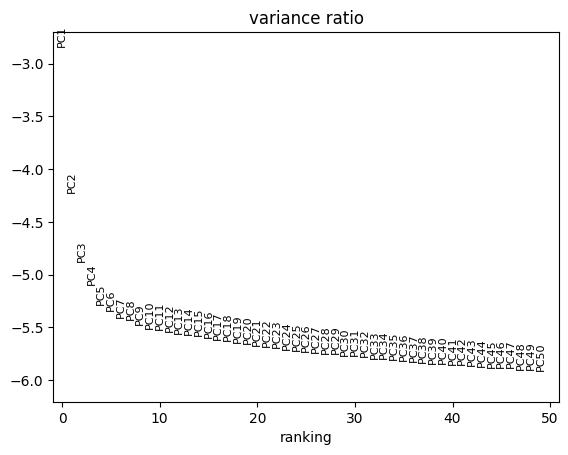

UMAP computed.


In [9]:
# Preprocessing: log-transform → filter low-expression genes → HVGs → PCA → neighbors → UMAP
adata_pp = adata_time.copy()

# Log2(FPKM + 1) transform
adata_pp.X = np.log2(adata_pp.X + 1)

# Drop genes expressed in fewer than 10 cells
sc.pp.filter_genes(adata_pp, min_cells=10)
print(f"Genes after low-expression filter: {adata_pp.n_vars:,}")

# Select top 2000 highly variable genes for dimensionality reduction
sc.pp.highly_variable_genes(adata_pp, n_top_genes=2000, flavor='seurat')
print(f"Highly variable genes selected: {adata_pp.var['highly_variable'].sum()}")

# PCA on HVGs
sc.tl.pca(adata_pp, use_highly_variable=True, n_comps=50, svd_solver='arpack')

# kNN graph and UMAP
sc.pp.neighbors(adata_pp, n_neighbors=15, n_pcs=30)
# plot eigenvalue decay to check how many PCs to use
sc.pl.pca_variance_ratio(adata_pp, log=True, n_pcs=50)
sc.tl.umap(adata_pp, random_state=42)
print("UMAP computed.")

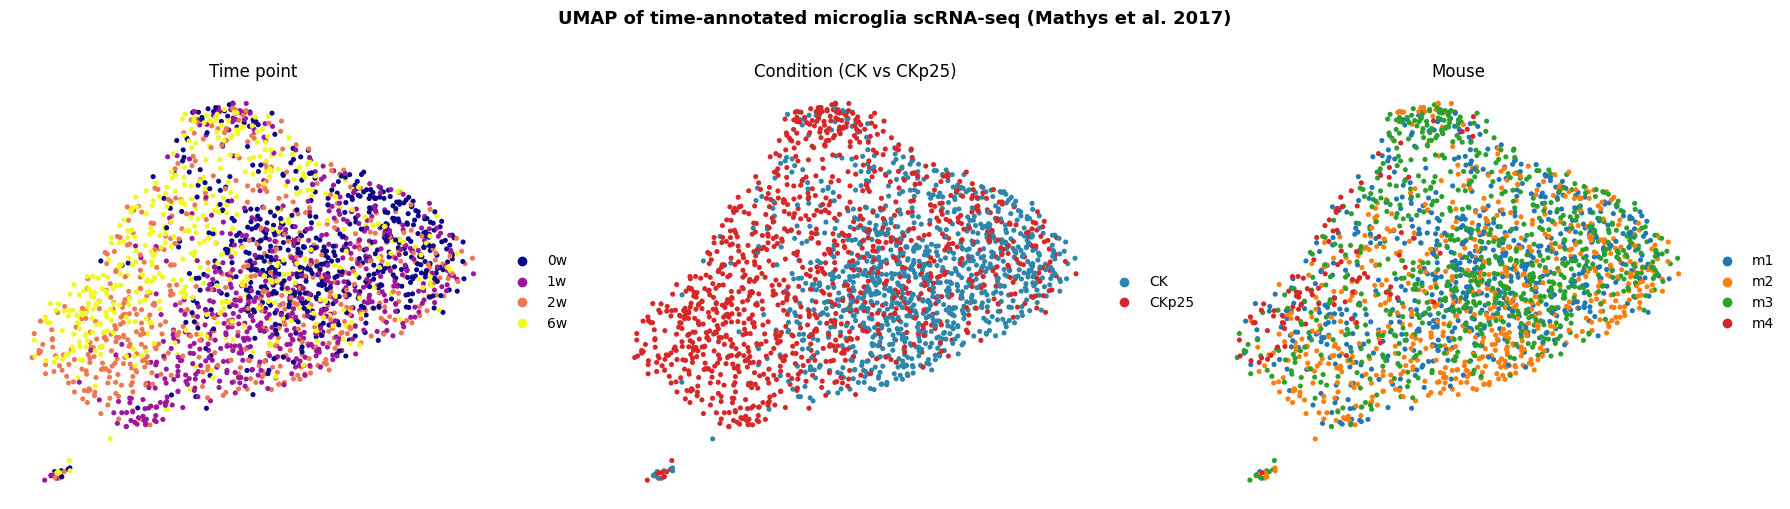

In [10]:
import matplotlib.pyplot as plt

# Enforce a consistent time-point ordering for the color palette
time_order = ['0w', '1w', '2w', '6w']
present_tps = [tp for tp in time_order if tp in adata_pp.obs['time_point'].values]
adata_pp.obs['time_point'] = pd.Categorical(
    adata_pp.obs['time_point'], categories=present_tps, ordered=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.umap(adata_pp, color='time_point', ax=axes[0], show=False,
           title='Time point', palette='plasma', frameon=False)
sc.pl.umap(adata_pp, color='condition', ax=axes[1], show=False,
           title='Condition (CK vs CKp25)', palette=['#2E86AB', '#D62828'], frameon=False)
sc.pl.umap(adata_pp, color='mouse', ax=axes[2], show=False,
           title='Mouse', frameon=False)

plt.suptitle('UMAP of time-annotated microglia scRNA-seq (Mathys et al. 2017)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/GSE103334/umap_time_condition_mouse.png', dpi=1200, bbox_inches='tight')
plt.show()

Time points used : ['0w', '1w', '2w', '6w']  (n_steps = 3)
Cells per step:
  0w: CK = 288, CKp25 = 288
  1w: CK = 288, CKp25 = 288
  2w: CK = 288, CKp25 = 288
  6w: CK = 192, CKp25 = 288

Running reconstruct_cf  (n=3, 15 PCs) ...
Done.


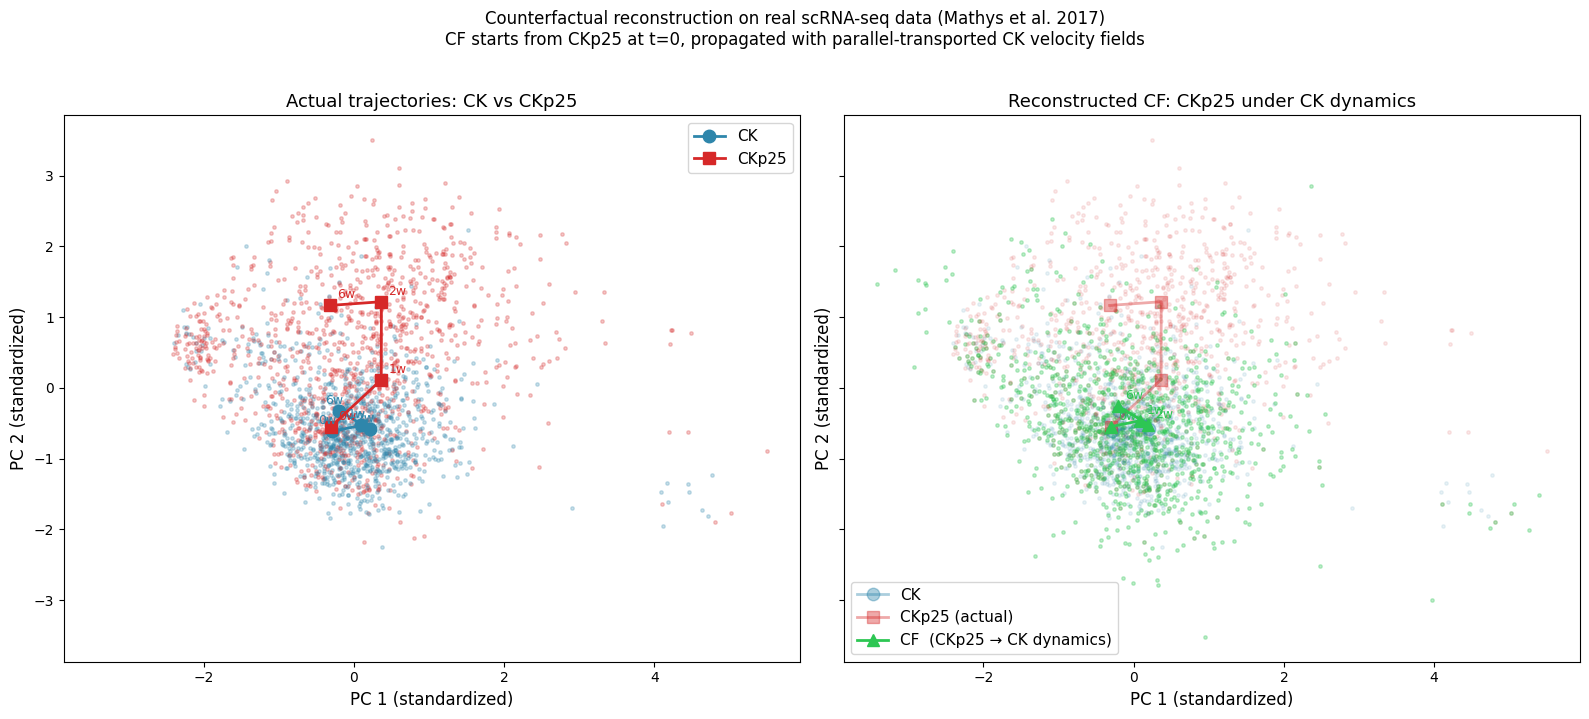

In [13]:


# ── Working space: top n_pcs principal components, standardized to unit variance
# Standardizing keeps coordinates O(1), so floating-point drift in PT stays < 1e-8.
n_pcs = 15
pca_raw = adata_pp.obsm['X_pca'][:, :n_pcs]
pca_std = pca_raw.std(axis=0)
pca     = pca_raw / pca_std          # each PC now has unit variance across all cells
obs     = adata_pp.obs

def get_pca(cond, tp):
    mask = (obs['condition'] == cond) & (obs['time_point'] == tp)
    return pca[mask.values]

# ── Trajectories: use time points present in both conditions ──────────────────
all_tps    = ['0w', '1w', '2w', '6w']
common_tps = [tp for tp in all_tps
              if len(get_pca('CK', tp)) > 0 and len(get_pca('CKp25', tp)) > 0]
n_steps    = len(common_tps) - 1

print(f"Time points used : {common_tps}  (n_steps = {n_steps})")

control_samples = [get_pca('CK',    tp) for tp in common_tps]
ckp25_samples   = [get_pca('CKp25', tp) for tp in common_tps]
cf_0            = get_pca('CKp25', common_tps[0])  # CF starts from CKp25 @ t=0

print("Cells per step:")
for tp, ck, cp in zip(common_tps, control_samples, ckp25_samples):
    print(f"  {tp}: CK = {len(ck)}, CKp25 = {len(cp)}")

# ── Reconstruct counterfactual ────────────────────────────────────────────────
print(f"\nRunning reconstruct_cf  (n={n_steps}, {n_pcs} PCs) ...")
cf_curve = reconstruct_cf(control_samples, cf_0, n=n_steps, project=False, tol=1e-6)
print("Done.")

# ── Visualise in PC1-PC2 space ────────────────────────────────────────────────
COL_CK   = '#2E86AB'
COL_CP25 = '#D62828'
COL_CF   = '#2DC653'

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
for ax in axes:
    ax.set_xlabel('PC 1 (standardized)', fontsize=12)
    ax.set_ylabel('PC 2 (standardized)', fontsize=12)

ck_means    = np.array([s.mean(0) for s in control_samples])
ckp25_means = np.array([s.mean(0) for s in ckp25_samples])
cf_means    = np.array([m.locs.mean(0) for m in cf_curve])

# Left: actual CK vs actual CKp25
for i in range(len(common_tps)):
    axes[0].scatter(control_samples[i][:, 0], control_samples[i][:, 1],
                    color=COL_CK,   alpha=0.25, s=6, rasterized=True)
    axes[0].scatter(ckp25_samples[i][:, 0],   ckp25_samples[i][:, 1],
                    color=COL_CP25, alpha=0.25, s=6, rasterized=True)
axes[0].plot(ck_means[:, 0],    ck_means[:, 1],    'o-', color=COL_CK,   lw=2, ms=9, label='CK')
axes[0].plot(ckp25_means[:, 0], ckp25_means[:, 1], 's-', color=COL_CP25, lw=2, ms=9, label='CKp25')
for i, tp in enumerate(common_tps):
    axes[0].annotate(tp, ck_means[i, :2],    xytext=(-10, 5), textcoords='offset points', fontsize=9, color=COL_CK)
    axes[0].annotate(tp, ckp25_means[i, :2], xytext=(  5, 5), textcoords='offset points', fontsize=9, color=COL_CP25)
axes[0].set_title('Actual trajectories: CK vs CKp25', fontsize=13)
axes[0].legend(fontsize=11)

# Right: actual trajectories (faded) + reconstructed CF
for i in range(len(common_tps)):
    axes[1].scatter(control_samples[i][:, 0], control_samples[i][:, 1],
                    color=COL_CK,   alpha=0.10, s=6, rasterized=True)
    axes[1].scatter(ckp25_samples[i][:, 0],   ckp25_samples[i][:, 1],
                    color=COL_CP25, alpha=0.10, s=6, rasterized=True)
    axes[1].scatter(cf_curve[i].locs[:, 0],   cf_curve[i].locs[:, 1],
                    color=COL_CF,   alpha=0.30, s=6, rasterized=True)
axes[1].plot(ck_means[:, 0],    ck_means[:, 1],    'o-', color=COL_CK,   lw=2, ms=9, alpha=0.4, label='CK')
axes[1].plot(ckp25_means[:, 0], ckp25_means[:, 1], 's-', color=COL_CP25, lw=2, ms=9, alpha=0.4, label='CKp25 (actual)')
axes[1].plot(cf_means[:, 0],    cf_means[:, 1],    '^-', color=COL_CF,   lw=2, ms=9,            label='CF  (CKp25 → CK dynamics)')
for i, tp in enumerate(common_tps):
    axes[1].annotate(tp, cf_means[i, :2], xytext=(5, 5), textcoords='offset points', fontsize=9, color=COL_CF)
axes[1].set_title('Reconstructed CF: CKp25 under CK dynamics', fontsize=13)
axes[1].legend(fontsize=11)

plt.suptitle(
    'Counterfactual reconstruction on real scRNA-seq data (Mathys et al. 2017)\n'
    'CF starts from CKp25 at t=0, propagated with parallel-transported CK velocity fields',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
from umap import UMAP

# ── Stack all three trajectories into one array ───────────────────────────────
all_locs   = []
traj_label = []   # 'CK', 'CKp25', 'CF'
tp_label   = []

for i, tp in enumerate(common_tps):
    for locs, name in [
        (control_samples[i],  'CK'),
        (ckp25_samples[i],    'CKp25'),
        (cf_curve[i].locs,    'CF'),
    ]:
        all_locs.append(locs)
        traj_label.extend([name] * len(locs))
        tp_label.extend([tp]   * len(locs))

all_locs   = np.vstack(all_locs)
traj_label = np.array(traj_label)
tp_label   = np.array(tp_label)

print(f"Total points for joint UMAP: {len(all_locs):,}")

# ── Joint UMAP embedding ──────────────────────────────────────────────────────
reducer   = UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42)
embedding = reducer.fit_transform(all_locs)
u1, u2    = embedding[:, 0], embedding[:, 1]
print("UMAP done.")


Total points for joint UMAP: 3,360


/home/tristan/Research/Sp26/WPT/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


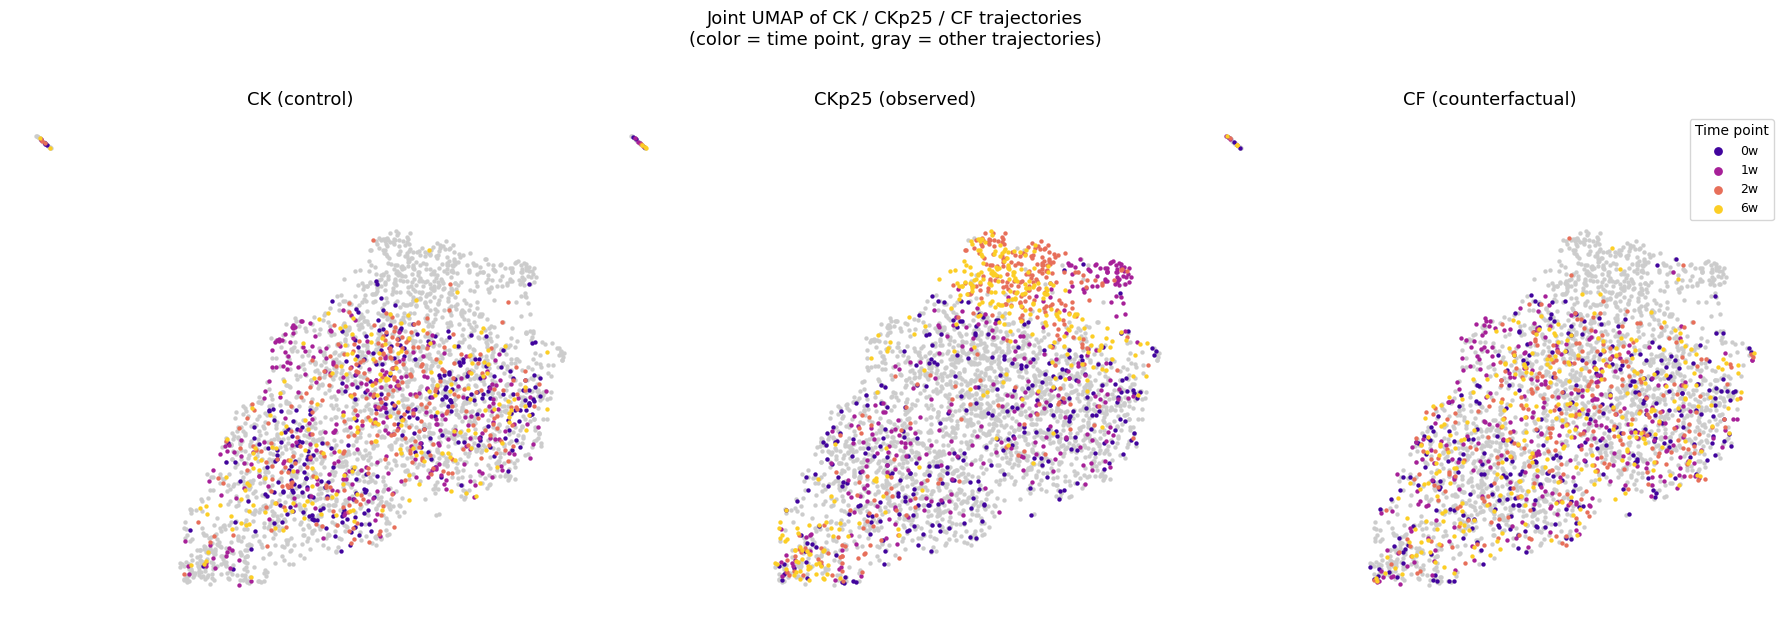

In [15]:

# ── Plot ──────────────────────────────────────────────────────────────────────
tp_colors = dict(zip(common_tps, [plt.cm.plasma(v) for v in np.linspace(0.1, 0.9, len(common_tps))]))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, (hi, title) in zip(axes, [('CK',    'CK (control)'),
                                   ('CKp25', 'CKp25 (observed)'),
                                   ('CF',    'CF (counterfactual)')]):
    # everything else: gray
    gray_mask = traj_label != hi
    ax.scatter(u1[gray_mask], u2[gray_mask],
               c="#cccccc00", s=10, alpha=1, linewidths=0, rasterized=True)

    # highlighted trajectory: colored by time point
    for tp in common_tps:
        mask = (traj_label == hi) & (tp_label == tp)
        ax.scatter(u1[mask], u2[mask],
                   c=[tp_colors[tp]], s=10, alpha=1, linewidths=0,
                   rasterized=True, label=tp)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.axis('off')

axes[0].set_ylabel('UMAP 2', fontsize=11)
axes[-1].legend(title='Time point', fontsize=9, title_fontsize=10,
                loc='best', markerscale=2)

plt.suptitle('Joint UMAP of CK / CKp25 / CF trajectories\n(color = time point, gray = other trajectories)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

CKp25@6w: 288 cells   CF@6w: 288 cells
Computing OT coupling (CKp25 → CF) ...

Top 20 genes by |mean Δlog₂(FPKM+1)|  (t = 6w):

Rank  Gene                      Mean Δ     Std Δ
──────────────────────────────────────────────────
   1  Apoe                     -5.9501    3.6138
   2  Ifi27l2a                 -5.3323    4.5414
   3  Cd74                     -4.9027    4.4181
   4  Lgals3bp                 -4.9009    3.5620
   5  Lyz2                     -4.7722    4.0236
   6  H2-D1                    -4.7610    3.7159
   7  H2-Q7                    -4.4804    3.8050
   8  Cst7                     -4.1959    4.5539
   9  Ifitm3                   -4.0120    4.4182
  10  Clec7a                   -3.9026    3.7766
  11  Adrb2                    +3.8823    3.0371
  12  Axl                      -3.8785    2.9334
  13  Slc2a5                   +3.7421    3.2300
  14  P2ry12                   +3.5860    3.2839
  15  H2-K1                    -3.5065    3.5680
  16  P2ry13                   +3.463

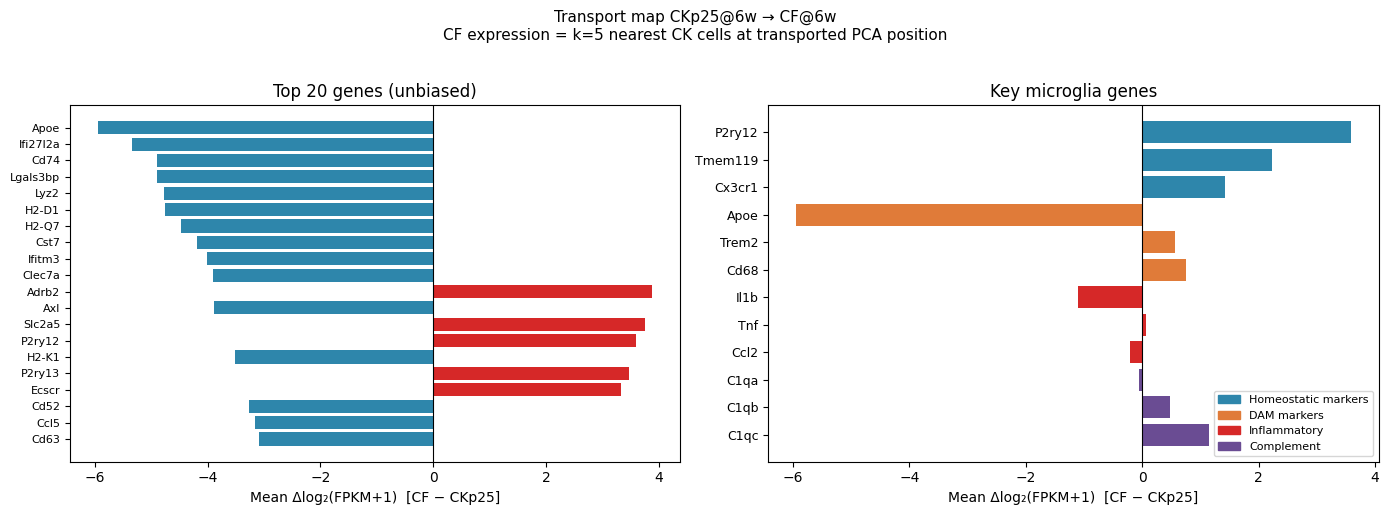

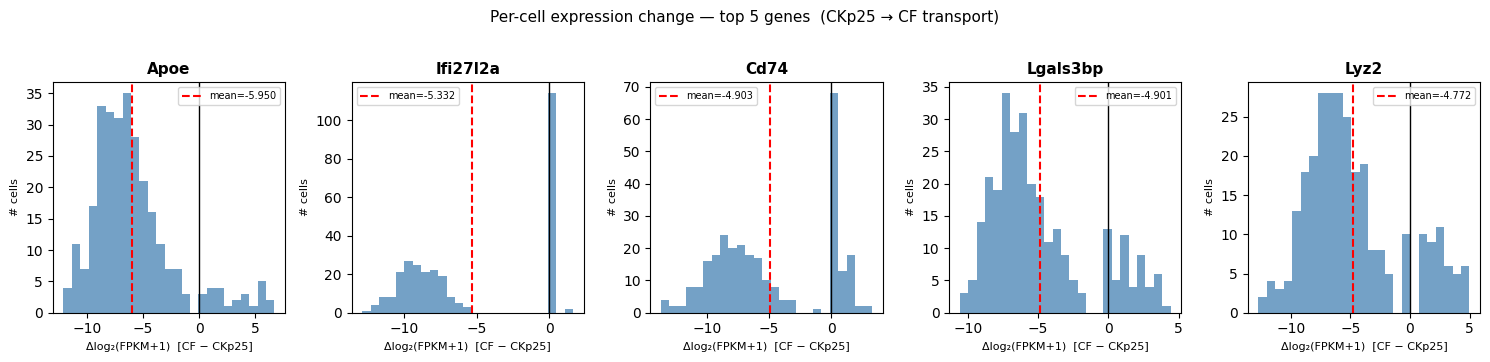

In [21]:

# transport map: CKp25_final → CF_final — gene changes via nearest-CK lookup at transported position
from src.pt import EmpiricalMeasure, barycentric_projection_tangent, wasserstein_logmap
from scipy.spatial import cKDTree
from matplotlib.patches import Patch

# ── 1. Final time-point arrays ────────────────────────────────────────────────
tp_final        = common_tps[-1]
ckp25_final_pca = ckp25_samples[-1]    # (n_src, n_pcs) standardised
cf_final_pca    = cf_curve[-1].locs    # (n_dst, n_pcs) standardised
ck_final_pca    = control_samples[-1]  # (n_ck,  n_pcs) standardised
n_src           = len(ckp25_final_pca)
print(f"CKp25@{tp_final}: {n_src} cells   CF@{tp_final}: {len(cf_final_pca)} cells")

# ── 2. OT: CKp25_final → CF_final ────────────────────────────────────────────
w_src = np.ones(n_src) / n_src
w_dst = cf_curve[-1].weights / cf_curve[-1].weights.sum()

src_meas = EmpiricalMeasure(locs=ckp25_final_pca, weights=w_src)
dst_meas = EmpiricalMeasure(locs=cf_final_pca,    weights=w_dst)
print("Computing OT coupling (CKp25 → CF) ...")
tan_final = wasserstein_logmap(src_meas, dst_meas)

if tan_final.coupling is not None:
    tan_vel = barycentric_projection_tangent(tan_final)
else:
    tan_vel = tan_final
vels = tan_vel.vels    # (n_src, n_pcs) displacements in standardised PCA

# ── 3. Gene expression: CKp25 actual vs nearest-CK at transported position ────
cf_pos = ckp25_final_pca + vels         # expected CF position per source cell

tree   = cKDTree(ck_final_pca)
_, nn_idx = tree.query(cf_pos, k=5)     # (n_src, 5) indices into ck_final_pca

mask_ckp25 = (obs['condition'] == 'CKp25') & (obs['time_point'] == tp_final)
mask_ck    = (obs['condition'] == 'CK')    & (obs['time_point'] == tp_final)
idx_ckp25  = np.where(mask_ckp25.values)[0]
idx_ck     = np.where(mask_ck.values)[0]

X = adata_pp.X if not hasattr(adata_pp.X, 'toarray') else adata_pp.X.toarray()
X_ckp25 = X[idx_ckp25]                  # (n_src, n_vars)
X_ck    = X[idx_ck]                     # (n_ck,  n_vars)

X_cf      = X_ck[nn_idx].mean(axis=1)   # (n_src, n_vars) — avg of 5 nearest CK neighbours
delta_expr = X_cf - X_ckp25             # positive = higher in CF/CK-like

# ── 4. Per-gene statistics & ranking ─────────────────────────────────────────
mean_delta = delta_expr.mean(axis=0)
gene_names = np.array(adata_pp.var_names)
gene2idx   = {g: i for i, g in enumerate(gene_names)}
order      = np.argsort(np.abs(mean_delta))[::-1]

top_n = 20
top_5 = 5
top_idx = order[:top_n]
print(f"\nTop {top_n} genes by |mean Δlog₂(FPKM+1)|  (t = {tp_final}):\n")
print(f"{'Rank':>4}  {'Gene':<20s}  {'Mean Δ':>10s}  {'Std Δ':>8s}")
print("─" * 50)
for rank, gi in enumerate(top_idx, 1):
    print(f"{rank:>4}  {gene_names[gi]:<20s}  {mean_delta[gi]:>+10.4f}  {delta_expr[:, gi].std():>8.4f}")

key_genes = {
    'Homeostatic markers': ['P2ry12', 'Tmem119', 'Cx3cr1'],
    'DAM markers':         ['Apoe',   'Trem2',   'Cd68'],
    'Inflammatory':        ['Il1b',   'Tnf',     'Ccl2'],
    'Complement':          ['C1qa',   'C1qb',    'C1qc'],
}
cat_colors = {
    'Homeostatic markers': '#2E86AB',
    'DAM markers':         '#E07B39',
    'Inflammatory':        '#D62828',
    'Complement':          '#6A4C93',
}
rank_map = {gi: r + 1 for r, gi in enumerate(order)}
print(f"\nKey-gene transport changes  (t = {tp_final}):\n")
print(f"{'Category':<22s}  {'Gene':<10s}  {'Mean Δ':>10s}  {'Rank':>6s}")
print("─" * 54)
for cat, genes in key_genes.items():
    for g in genes:
        if g in gene2idx:
            gi = gene2idx[g]
            print(f"{cat:<22s}  {g:<10s}  {mean_delta[gi]:>+10.4f}  {rank_map[gi]:>6d}")
        else:
            print(f"{cat:<22s}  {g:<10s}  {'(not in vars)':>13s}  {'—':>6s}")

# shared across baseline cell
bar_labels = [g for cat, genes in key_genes.items() for g in genes]
bar_clrs   = [cat_colors[cat] for cat, genes in key_genes.items() for g in genes]
y_pos      = np.arange(len(bar_labels))

# ── 5. Figure 1: top-20 bar + key-gene bar ────────────────────────────────────
bar_vals_t = [mean_delta[gene2idx[g]] if g in gene2idx else 0. for g in bar_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_top = ['#D62828' if mean_delta[gi] > 0 else '#2E86AB' for gi in top_idx]
axes[0].barh(range(top_n), mean_delta[top_idx[::-1]], color=colors_top[::-1])
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(gene_names[top_idx[::-1]], fontsize=8)
axes[0].set_xlabel('Mean Δlog₂(FPKM+1)  [CF − CKp25]', fontsize=10)
axes[0].set_title(f'Top {top_n} genes (unbiased)', fontsize=12)
axes[0].axvline(0, color='k', lw=0.8)

axes[1].barh(y_pos, bar_vals_t[::-1], color=bar_clrs[::-1])
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(bar_labels[::-1], fontsize=9)
axes[1].set_xlabel('Mean Δlog₂(FPKM+1)  [CF − CKp25]', fontsize=10)
axes[1].set_title('Key microglia genes', fontsize=12)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].legend(handles=[Patch(color=c, label=l) for l, c in cat_colors.items()],
               fontsize=8, loc='lower right')

plt.suptitle(f'Transport map CKp25@{tp_final} → CF@{tp_final}\n'
             'CF expression = k=5 nearest CK cells at transported PCA position',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/GSE103334/transport_gene_changes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. Figure 2: per-cell delta histograms for top-5 genes ────────────────────
fig2, axes2 = plt.subplots(1, top_5, figsize=(15, 3.5))
for ax, gi in zip(axes2, order[:top_5]):
    vals = delta_expr[:, gi]
    ax.hist(vals, bins=25, color='steelblue', alpha=0.75, edgecolor='none')
    ax.axvline(0,           color='k',   lw=1.0)
    ax.axvline(vals.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={vals.mean():.3f}')
    ax.set_title(gene_names[gi], fontsize=11, fontweight='bold')
    ax.set_xlabel('Δlog₂(FPKM+1)  [CF − CKp25]', fontsize=8)
    ax.set_ylabel('# cells', fontsize=8)
    ax.legend(fontsize=7)

fig2.suptitle(f'Per-cell expression change — top {top_5} genes  (CKp25 → CF transport)',
              fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/GSE103334/transport_top5_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


Baseline top 20 genes by |mean Δlog₂(FPKM+1)|  (t = 6w):

Rank  Gene                      Mean Δ     Std Δ
──────────────────────────────────────────────────
   1  Apoe                     -5.9569    3.2968
   2  Ifi27l2a                 -5.1628    4.5198
   3  Lgals3bp                 -5.0832    3.3706
   4  H2-D1                    -4.8318    3.3315
   5  H2-Q7                    -4.5297    3.8023
   6  Cd74                     -4.5127    4.1884
   7  Lyz2                     -4.3034    3.5199
   8  Cst7                     -3.9524    4.5027
   9  Clec7a                   -3.8189    3.7913
  10  Ifitm3                   -3.7565    4.2230
  11  H2-K1                    -3.6747    2.9330
  12  Adrb2                    +3.6146    3.0038
  13  Axl                      -3.6051    2.8487
  14  Rpl10a                   -3.0698    2.8107
  15  Rplp2                    -2.9935    3.9068
  16  Cd52                     -2.9479    4.0641
  17  Cd83                     -2.9131    3.5421
  18  H2-

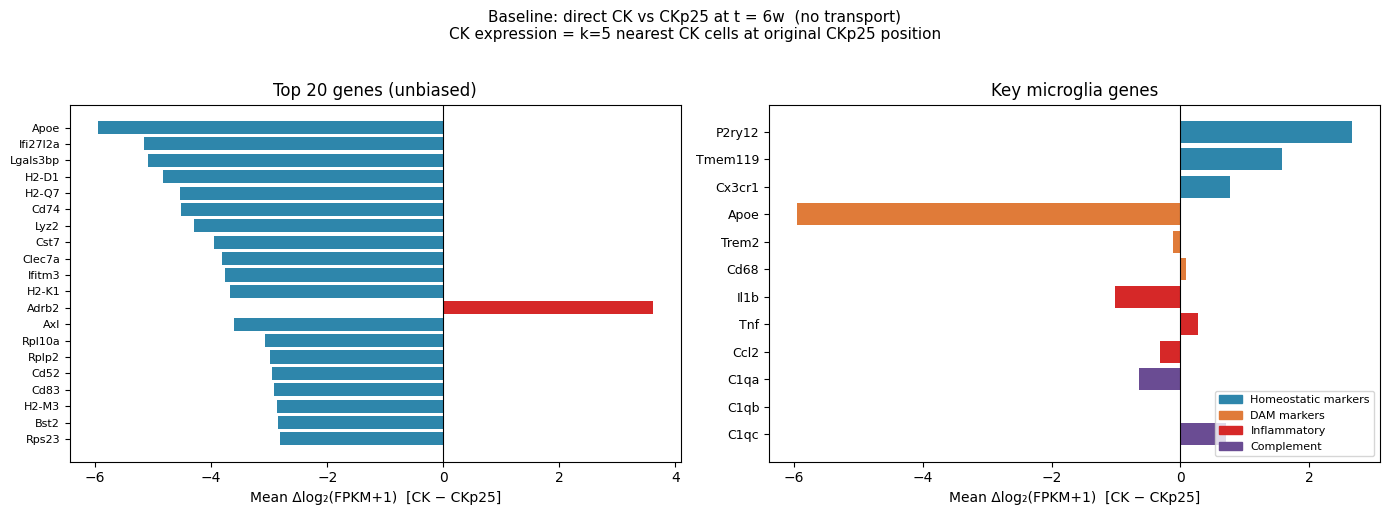

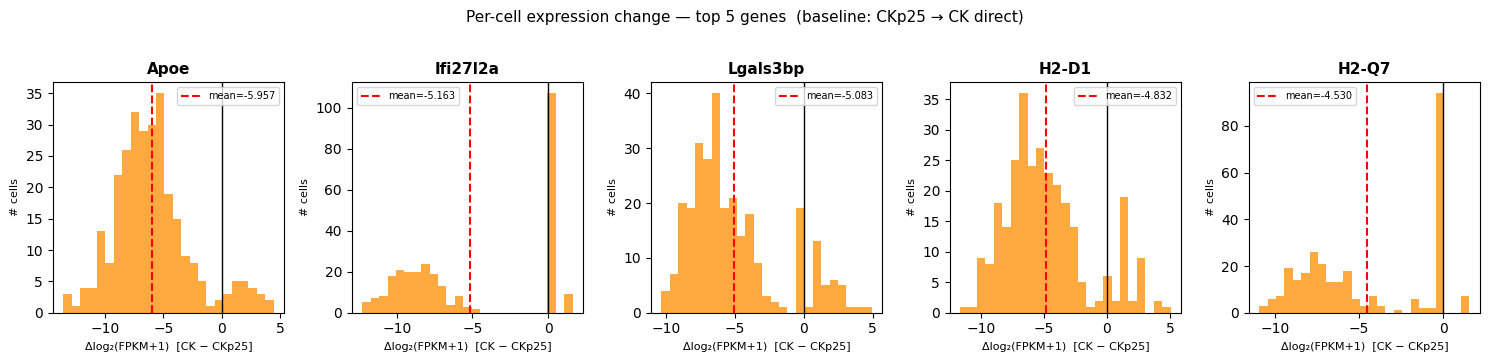

In [20]:

# baseline: direct CKp25 vs CK at final time point — nearest-CK at *original* position
# same structure as transport cell for direct comparability

# ── 1. Nearest-CK at original CKp25 position (no transport) ──────────────────
tree_base     = cKDTree(ck_final_pca)
_, nn_idx_b   = tree_base.query(ckp25_final_pca, k=5)   # (n_src, 5)

X_ck_base  = X_ck[nn_idx_b].mean(axis=1)    # (n_src, n_vars)
delta_base = X_ck_base - X_ckp25            # positive = higher in CK

# ── 2. Per-gene statistics & ranking ─────────────────────────────────────────
mean_base  = delta_base.mean(axis=0)
order_base = np.argsort(np.abs(mean_base))[::-1]
top_idx_b  = order_base[:top_n]

print(f"Baseline top {top_n} genes by |mean Δlog₂(FPKM+1)|  (t = {tp_final}):\n")
print(f"{'Rank':>4}  {'Gene':<20s}  {'Mean Δ':>10s}  {'Std Δ':>8s}")
print("─" * 50)
for rank, gi in enumerate(top_idx_b, 1):
    print(f"{rank:>4}  {gene_names[gi]:<20s}  {mean_base[gi]:>+10.4f}  {delta_base[:, gi].std():>8.4f}")

rank_map_b = {gi: r + 1 for r, gi in enumerate(order_base)}
print(f"\nBaseline key-gene changes  (t = {tp_final}):\n")
print(f"{'Category':<22s}  {'Gene':<10s}  {'Mean Δ':>10s}  {'Rank':>6s}")
print("─" * 54)
for cat, genes in key_genes.items():
    for g in genes:
        if g in gene2idx:
            gi = gene2idx[g]
            print(f"{cat:<22s}  {g:<10s}  {mean_base[gi]:>+10.4f}  {rank_map_b[gi]:>6d}")
        else:
            print(f"{cat:<22s}  {g:<10s}  {'(not in vars)':>13s}  {'—':>6s}")

# ── 3. Figure 1: top-20 bar + key-gene bar ────────────────────────────────────
bar_vals_b = [mean_base[gene2idx[g]] if g in gene2idx else 0. for g in bar_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_b = ['#D62828' if mean_base[gi] > 0 else '#2E86AB' for gi in top_idx_b]
axes[0].barh(range(top_n), mean_base[top_idx_b[::-1]], color=colors_b[::-1])
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(gene_names[top_idx_b[::-1]], fontsize=8)
axes[0].set_xlabel('Mean Δlog₂(FPKM+1)  [CK − CKp25]', fontsize=10)
axes[0].set_title(f'Top {top_n} genes (unbiased)', fontsize=12)
axes[0].axvline(0, color='k', lw=0.8)

axes[1].barh(y_pos, bar_vals_b[::-1], color=bar_clrs[::-1])
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(bar_labels[::-1], fontsize=9)
axes[1].set_xlabel('Mean Δlog₂(FPKM+1)  [CK − CKp25]', fontsize=10)
axes[1].set_title('Key microglia genes', fontsize=12)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].legend(handles=[Patch(color=c, label=l) for l, c in cat_colors.items()],
               fontsize=8, loc='lower right')

plt.suptitle(f'Baseline: direct CK vs CKp25 at t = {tp_final}  (no transport)\n'
             'CK expression = k=5 nearest CK cells at original CKp25 position',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/GSE103334/baseline_gene_changes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Figure 2: per-cell delta histograms for top-5 genes ────────────────────
fig2, axes2 = plt.subplots(1, top_5, figsize=(15, 3.5))
for ax, gi in zip(axes2, order_base[:top_5]):
    vals = delta_base[:, gi]
    ax.hist(vals, bins=25, color='darkorange', alpha=0.75, edgecolor='none')
    ax.axvline(0,           color='k',   lw=1.0)
    ax.axvline(vals.mean(), color='red', lw=1.5, linestyle='--', label=f'mean={vals.mean():.3f}')
    ax.set_title(gene_names[gi], fontsize=11, fontweight='bold')
    ax.set_xlabel('Δlog₂(FPKM+1)  [CK − CKp25]', fontsize=8)
    ax.set_ylabel('# cells', fontsize=8)
    ax.legend(fontsize=7)

fig2.suptitle(f'Per-cell expression change — top {top_5} genes  (baseline: CKp25 → CK direct)',
              fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/GSE103334/baseline_top5_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
